# Province Climate Characterization

This notebook produces the tables and figures used to characterize the three study provinces
in the paper's *Study Setup* section:

- **Table:** Key climate statistics (temperature, humidity, precipitation, solar, pressure)
  across Cáceres, Cádiz, and Zaragoza — daytime and annual aggregations from ERA5-Land.
- **Figure A:** Map of Spain showing province locations and plant sites.
- **Figure B:** Seasonal climate comparison — monthly mean temperature + SSRD, 3-province overlay.
- **Figure C:** PV generation seasonality — monthly mean generation comparison.
- **Figure D:** Weather variability — box plots of key features, per province.

All data come from the assembled datasets produced by the `1_data_assembly.ipynb` pipeline.
Period: 2023-01-01 to 2025-12-31 (3 full years, ERA5-Land capacity-weighted over 8 plants each).

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT = os.path.abspath(os.getcwd())
FIGURES_DIR = os.path.join(ROOT, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
PROVINCES = {
    'Cáceres':  {'dir': 'caceres',  'file': 'caceres_assembled_dataset.csv',
                 'capacity_mwp': 2463.01, 'region': 'Extremadura',
                 'climate': 'Inland semi-arid',
                 'lat': 39.47, 'lon': -6.37,   # centroid of the 8 plants
                 'color': '#E53935'},            # red
    'Cádiz':    {'dir': 'cadiz',    'file': 'cadiz_assembled_dataset.csv',
                 'capacity_mwp': 714.60,  'region': 'Andalucía',
                 'climate': 'Atlantic coastal',
                 'lat': 36.55, 'lon': -5.96,
                 'color': '#1E88E5'},            # blue
    'Zaragoza': {'dir': 'zaragoza', 'file': 'zaragoza_assembled_dataset.csv',
                 'capacity_mwp': 462.40,  'region': 'Aragón',
                 'climate': 'Ebro valley continental',
                 'lat': 41.47, 'lon': -0.62,
                 'color': '#43A047'},            # green
}

# ── Publication style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Setup complete.')

Setup complete.


## 1. Load Data

In [12]:
dfs = {}
for prov, info in PROVINCES.items():
    path = os.path.join(ROOT, info['dir'], 'data', info['file'])
    df = pd.read_csv(path, parse_dates=['datetime_utc'])
    df = df.set_index('datetime_utc').sort_index()

    # ── Derived columns ──────────────────────────────────────────────────────
    # Clear-sky index (daytime hours where clearsky_ghi > 10 W/m²)
    df['kt'] = np.where(df['clearsky_ghi'] > 10,
                        np.clip(df['ssrd_wm2'] / df['clearsky_ghi'], 0, 1.5),
                        np.nan)
    # Dewpoint depression
    df['dewpoint_depression_C'] = df['temperature_2m_C'] - df['dewpoint_2m_C']
    # Month and hour
    df['month'] = df.index.month
    df['hour']  = df.index.hour
    # Daytime flag
    df['is_daytime'] = df['solar_zenith'] < 90
    # Generation in MWh (column is labelled _gwh but unit is actually MWh throughout)
    df = df.rename(columns={'pv_generation_gwh': 'pv_generation_mwh'})

    dfs[prov] = df
    day = df[df['is_daytime']]
    print(f'{prov}: {len(df):,} rows | daytime rows: {len(day):,} | '
          f'period: {df.index[0].date()} to {df.index[-1].date()}')

Cáceres: 26,304 rows | daytime rows: 13,223 | period: 2023-01-01 to 2025-12-31
Cádiz: 26,304 rows | daytime rows: 13,279 | period: 2023-01-01 to 2025-12-31
Zaragoza: 26,304 rows | daytime rows: 13,296 | period: 2023-01-01 to 2025-12-31


## 2. Climate Statistics Table

Aggregated from ERA5-Land (capacity-weighted over 8 plants, 2023–2025).  
All-hours statistics for temperature/pressure/precipitation;  
daytime-only (zenith < 90°) statistics for irradiance and kt.

In [13]:
rows = []

for prov, df in dfs.items():
    day  = df[df['is_daytime']]
    day_kt = df[df['clearsky_ghi'] > 10]

    # Annual precipitation — ERA5 stores hourly accumulated values; sum over 3 years / 3
    annual_precip = df['total_precip_mm'].sum() / 3.0

    # Fraction of daytime hours that are 'cloudy' (kt < 0.5)
    kt_valid = day_kt['kt'].dropna()
    cloudy_frac = (kt_valid < 0.5).mean() * 100

    # Annual solar energy (sum of SSRD over all hours, daytime, divided by 1000 to get kWh/m²)
    annual_solar_kwh = day['ssrd_wm2'].sum() / 3.0 / 1000.0   # kWh/m²/yr approximation

    rows.append({
        'Province': prov,
        'Region': PROVINCES[prov]['region'],
        'Climate': PROVINCES[prov]['climate'],
        'Capacity (MWp)': PROVINCES[prov]['capacity_mwp'],

        # Temperature
        'Mean Temp (°C)': round(df['temperature_2m_C'].mean(), 1),
        'Min Temp (°C)':  round(df['temperature_2m_C'].min(), 1),
        'Max Temp (°C)':  round(df['temperature_2m_C'].max(), 1),
        'Temp Std (°C)':  round(df['temperature_2m_C'].std(), 1),

        # Humidity
        'Mean Dewpoint (°C)':   round(df['dewpoint_2m_C'].mean(), 1),
        'Mean Dew Depression (°C)': round(df['dewpoint_depression_C'].mean(), 1),

        # Precipitation
        'Annual Precip (mm/yr)': round(annual_precip, 0),

        # Pressure (altitude proxy)
        'Mean Pressure (hPa)': round(df['surface_pressure_hPa'].mean(), 1),

        # Solar
        'Mean Daytime SSRD (W/m²)': round(day['ssrd_wm2'].mean(), 1),
        'Mean kt (clearsky index)':  round(kt_valid.mean(), 3),
        'Cloudy fraction (kt<0.5, %)': round(cloudy_frac, 1),
        'Annual Solar Energy (kWh/m²/yr)': round(annual_solar_kwh, 0),
    })

stats = pd.DataFrame(rows).set_index('Province')

# ── Display ───────────────────────────────────────────────────────────────────
print('=== Climate Statistics by Province (ERA5-Land, 2023–2025) ===')
print(stats.T.to_string())

=== Climate Statistics by Province (ERA5-Land, 2023–2025) ===
Province                                  Cáceres             Cádiz                 Zaragoza
Region                                Extremadura         Andalucía                   Aragón
Climate                          Inland semi-arid  Atlantic coastal  Ebro valley continental
Capacity (MWp)                            2463.01             714.6                    462.4
Mean Temp (°C)                               17.3              19.2                     15.5
Min Temp (°C)                                -0.2               2.8                     -2.8
Max Temp (°C)                                41.1              40.4                     40.6
Temp Std (°C)                                 8.3               6.5                      8.5
Mean Dewpoint (°C)                            8.8              12.4                      6.8
Mean Dew Depression (°C)                      8.5               6.8                      8.7
Annual P

In [14]:
# ── Clean paper-ready table ──────────────────────────────────────────────────
paper_rows = []
for prov, df in dfs.items():
    day    = df[df['is_daytime']]
    day_kt = df[df['clearsky_ghi'] > 10]
    kt_valid = day_kt['kt'].dropna()
    annual_precip = df['total_precip_mm'].sum() / 3.0
    cloudy_frac   = (kt_valid < 0.5).mean() * 100

    paper_rows.append({
        'Province':             prov,
        'Region':               PROVINCES[prov]['region'],
        'Climate type':         PROVINCES[prov]['climate'],
        'Capacity':             f"{PROVINCES[prov]['capacity_mwp']:.0f} MWp",
        'Mean temp. (°C)':      f"{df['temperature_2m_C'].mean():.1f}",
        'Temp. range (°C)':     f"{df['temperature_2m_C'].min():.1f} – {df['temperature_2m_C'].max():.1f}",
        'Mean dewpoint (°C)':   f"{df['dewpoint_2m_C'].mean():.1f}",
        'Dew depression (°C)':  f"{df['dewpoint_depression_C'].mean():.1f}",
        'Precip. (mm yr⁻¹)':    f"{annual_precip:.0f}",
        'Mean pressure (hPa)':  f"{df['surface_pressure_hPa'].mean():.0f}",
        'Daytime SSRD (W m⁻²)': f"{day['ssrd_wm2'].mean():.0f}",
        'Clearsky index (kt)':  f"{kt_valid.mean():.3f}",
        'Cloudy fraction (%)':  f"{cloudy_frac:.1f}",
    })

paper = pd.DataFrame(paper_rows).set_index('Province')

# Print transposed for easy reading
print(paper.T.to_string())
print()
print('LaTeX-ready:')
print(paper.T.to_latex())

Province                       Cáceres             Cádiz                 Zaragoza
Region                     Extremadura         Andalucía                   Aragón
Climate type          Inland semi-arid  Atlantic coastal  Ebro valley continental
Capacity                      2463 MWp           715 MWp                  462 MWp
Mean temp. (°C)                   17.3              19.2                     15.5
Temp. range (°C)           -0.2 – 41.1        2.8 – 40.4              -2.8 – 40.6
Mean dewpoint (°C)                 8.8              12.4                      6.8
Dew depression (°C)                8.5               6.8                      8.7
Precip. (mm yr⁻¹)                  716               561                      397
Mean pressure (hPa)                973              1009                      954
Daytime SSRD (W m⁻²)               395               431                      389
Clearsky index (kt)              0.848             0.866                    0.892
Cloudy fraction 

## 3. Map — Real Spain Provinces (geopandas + Natural Earth)

Downloads the 1:10m Natural Earth admin-1 provinces shapefile, highlights the three study
provinces, and overlays the 8 PV plant locations per province.

In [ ]:
import geopandas as gpd
from matplotlib.lines import Line2D

# ── Download Natural Earth admin-1 provinces (cached after first run) ─────────
NE_URL = 'https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip'
print('Loading Natural Earth admin-1 provinces (downloads once, then cached)...')
provinces_world = gpd.read_file(NE_URL)
spain = provinces_world[provinces_world['admin'] == 'Spain'].copy()
print(f'Spain provinces found: {len(spain)}')

# ── Plant coordinates (8 plants per province) ────────────────────────────────
plant_coords = {
    'Cáceres': [
        (39.74, -6.13), (39.85, -5.87), (39.66, -7.40), (39.56, -6.29),
        (39.68, -6.07), (39.54, -5.59), (39.41, -5.68), (39.93, -5.74),
    ],
    'Cádiz': [
        (36.72, -5.69), (36.42, -5.74), (36.64, -6.15), (36.39, -5.90),
        (36.44, -5.71), (36.54, -5.87), (36.35, -5.49), (36.55, -6.18),
    ],
    'Zaragoza': [
        (41.18, -0.46), (41.37, -0.26), (41.28, -0.43), (41.17, -0.49),
        (41.49, -0.14), (41.34, -0.30), (41.45, -0.55), (41.26, -0.38),
    ],
}

fig, ax = plt.subplots(figsize=(9, 7))

# ── 1. All Spain provinces in neutral grey ────────────────────────────────────
spain.plot(ax=ax, color='#EBEBEB', edgecolor='#AAAAAA', linewidth=0.5)

# ── 2. Highlight the three study provinces ────────────────────────────────────
highlight_patches = []
for prov, info in PROVINCES.items():
    spain[spain['name'] == prov].plot(
        ax=ax, color=info['color'], alpha=0.45,
        edgecolor=info['color'], linewidth=1.5)
    highlight_patches.append(
        mpatches.Patch(
            facecolor=info['color'], alpha=0.6,
            edgecolor=info['color'], linewidth=1,
            label=f"{prov}  ({info['region']}, {info['capacity_mwp']:.0f} MWp)"))

# ── 3. PV plant locations ─────────────────────────────────────────────────────
for prov, coords in plant_coords.items():
    ax.scatter(
        [c[1] for c in coords], [c[0] for c in coords],
        color=PROVINCES[prov]['color'], s=70, zorder=5,
        edgecolors='white', linewidths=0.8)

# ── 4. Province name annotations ─────────────────────────────────────────────
label_cfg = {
    'Cáceres':  dict(xy=(-6.10, 39.55), xytext=(-8.20, 40.30), ha='right'),
    'Cádiz':    dict(xy=(-5.85, 36.55), xytext=(-7.80, 36.00), ha='right'),
    'Zaragoza': dict(xy=(-0.38, 41.32), xytext=( 1.20, 42.30), ha='left'),
}
for prov, cfg in label_cfg.items():
    ax.annotate(
        prov,
        xy=cfg['xy'], xytext=cfg['xytext'],
        fontsize=12, fontweight='bold', color=PROVINCES[prov]['color'],
        ha=cfg['ha'],
        arrowprops=dict(arrowstyle='->', color=PROVINCES[prov]['color'], lw=1.4),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'),
        zorder=6)

# ── 5. Legend — lower right to avoid overlapping Cádiz ───────────────────────
dot_handle = Line2D(
    [0], [0], marker='o', color='w',
    markerfacecolor='#555555', markersize=7,
    label='PV plant location (8 per province)')
ax.legend(
    handles=highlight_patches + [dot_handle],
    loc='lower right',       # <── right side, clear of Cádiz
    framealpha=0.92,
    fontsize=10)

# ── 6. Axes & cosmetics ───────────────────────────────────────────────────────
ax.set_xlim(-9.5, 4.5)
ax.set_ylim(35.3, 44.2)
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.set_title('Study provinces and PV plant locations in Spain', fontsize=13, pad=10)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'province_map.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/province_map.png')

## 4. Seasonal Climate Comparison

Monthly mean temperature and SSRD across all three provinces, showing the distinct seasonal signatures.

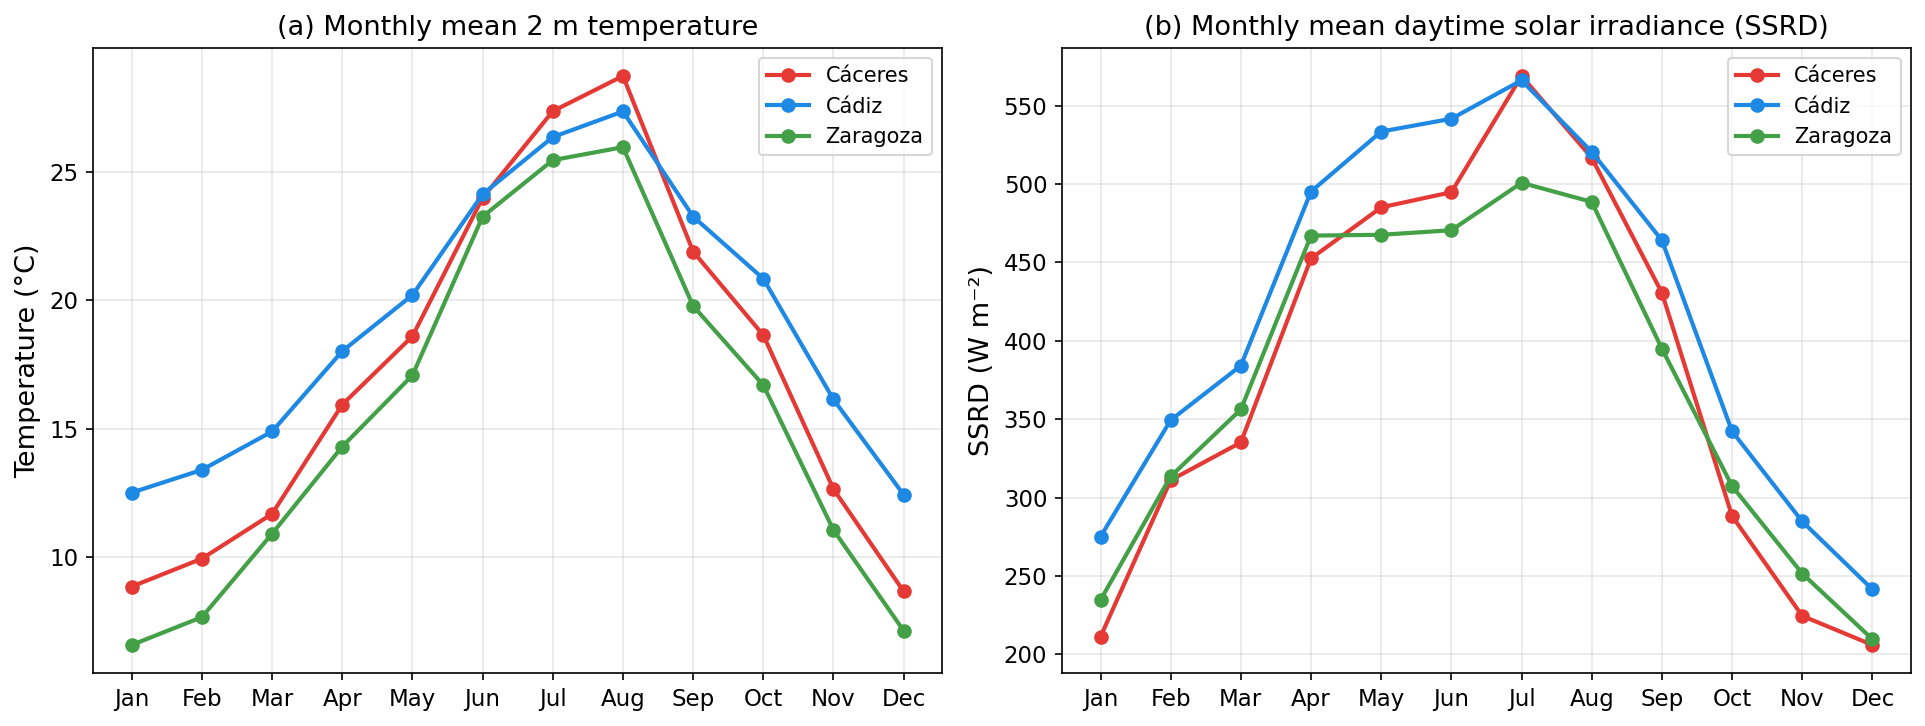

Saved: province_seasonal_climate.png


In [ ]:
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for prov, df in dfs.items():
    color = PROVINCES[prov]['color']
    day   = df[df['is_daytime']]

    # ── (a) Monthly mean temperature ─────────────────────────────────────────
    monthly_temp = df.groupby('month')['temperature_2m_C'].mean()
    axes[0].plot(monthly_temp.index, monthly_temp.values,
                 marker='o', color=color, lw=2, label=prov)

    # ── (b) Monthly mean daytime SSRD ────────────────────────────────────────
    monthly_ssrd = day.groupby('month')['ssrd_wm2'].mean()
    axes[1].plot(monthly_ssrd.index, monthly_ssrd.values,
                 marker='o', color=color, lw=2, label=prov)

axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(MONTHS)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('(a) Monthly mean 2 m temperature')
axes[0].legend()

axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(MONTHS)
axes[1].set_ylabel('SSRD (W m⁻²)')
axes[1].set_title('(b) Monthly mean daytime solar irradiance (SSRD)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'province_seasonal_climate.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/province_seasonal_climate.png')

## 5. Monthly PV Generation Comparison

Shows the seasonality and scale differences across provinces.  
Left panel: absolute MWh; right panel: capacity-normalized (MWh/MWp) to make provinces comparable.

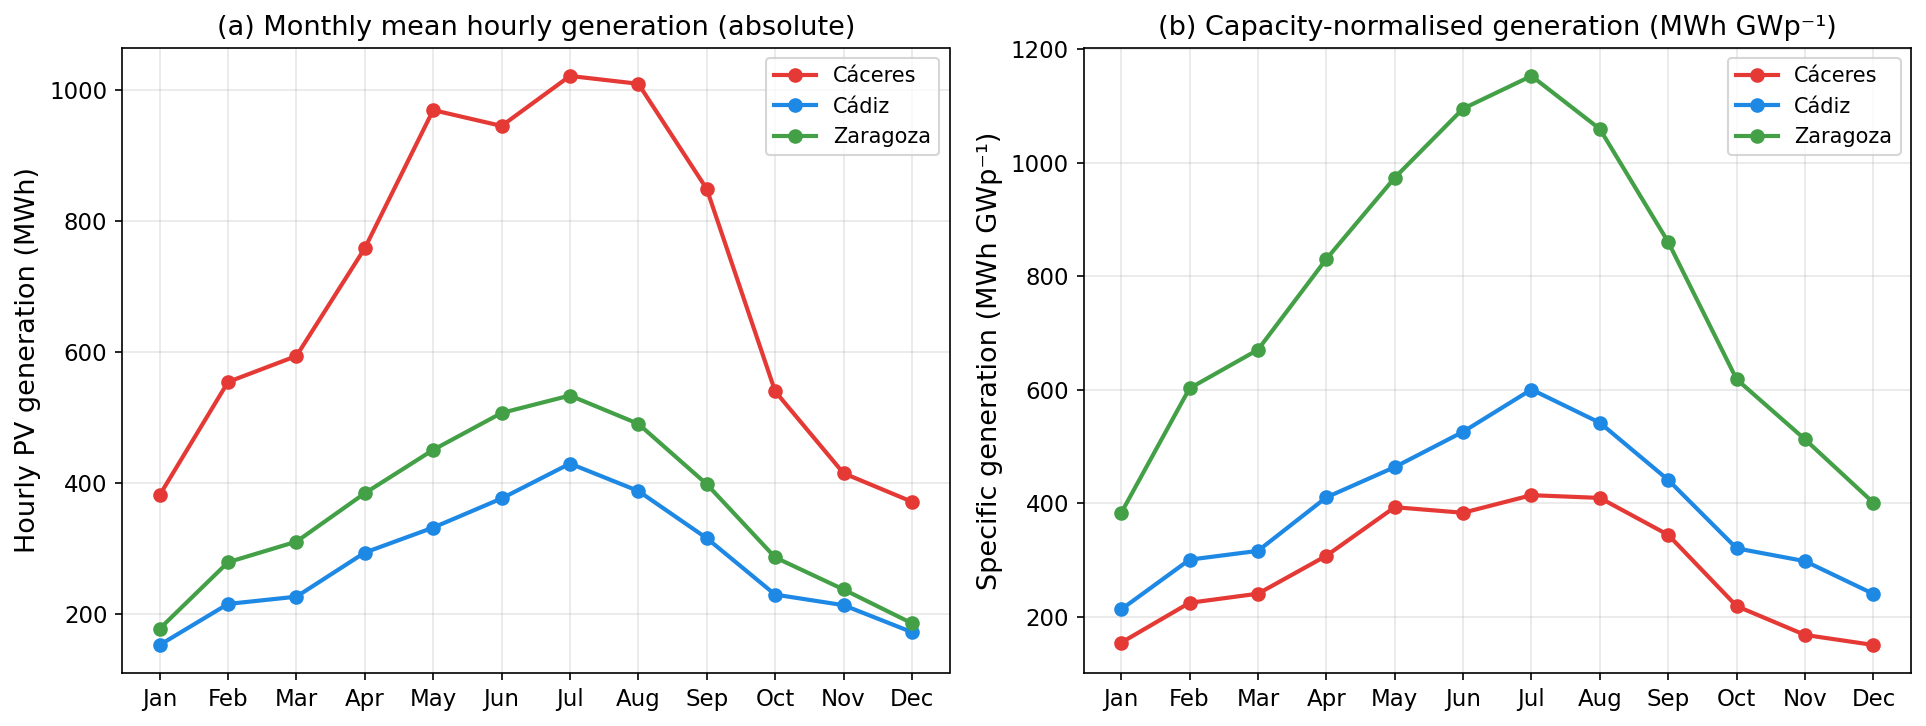

Saved: province_generation_seasonality.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for prov, df in dfs.items():
    color    = PROVINCES[prov]['color']
    capacity = PROVINCES[prov]['capacity_mwp']

    monthly_gen = df.groupby('month')['pv_generation_mwh'].mean()

    # Absolute
    axes[0].plot(monthly_gen.index, monthly_gen.values,
                 marker='o', color=color, lw=2, label=prov)

    # Capacity-normalised (specific yield, MWh/MWp)
    axes[1].plot(monthly_gen.index, monthly_gen.values / capacity * 1000,
                 marker='o', color=color, lw=2, label=prov)

for ax, title, ylabel in zip(
        axes,
        ['(a) Monthly mean hourly generation (absolute)',
         '(b) Capacity-normalised generation (MWh GWp⁻¹)'],
        ['Hourly PV generation (MWh)', 'Specific generation (MWh GWp⁻¹)']):
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTHS)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'province_generation_seasonality.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/province_generation_seasonality.png')

## 6. Weather Variability Box Plots

Side-by-side box plots for the key ERA5 predictors. Highlights distributional differences
between provinces that motivate the multi-province study design.

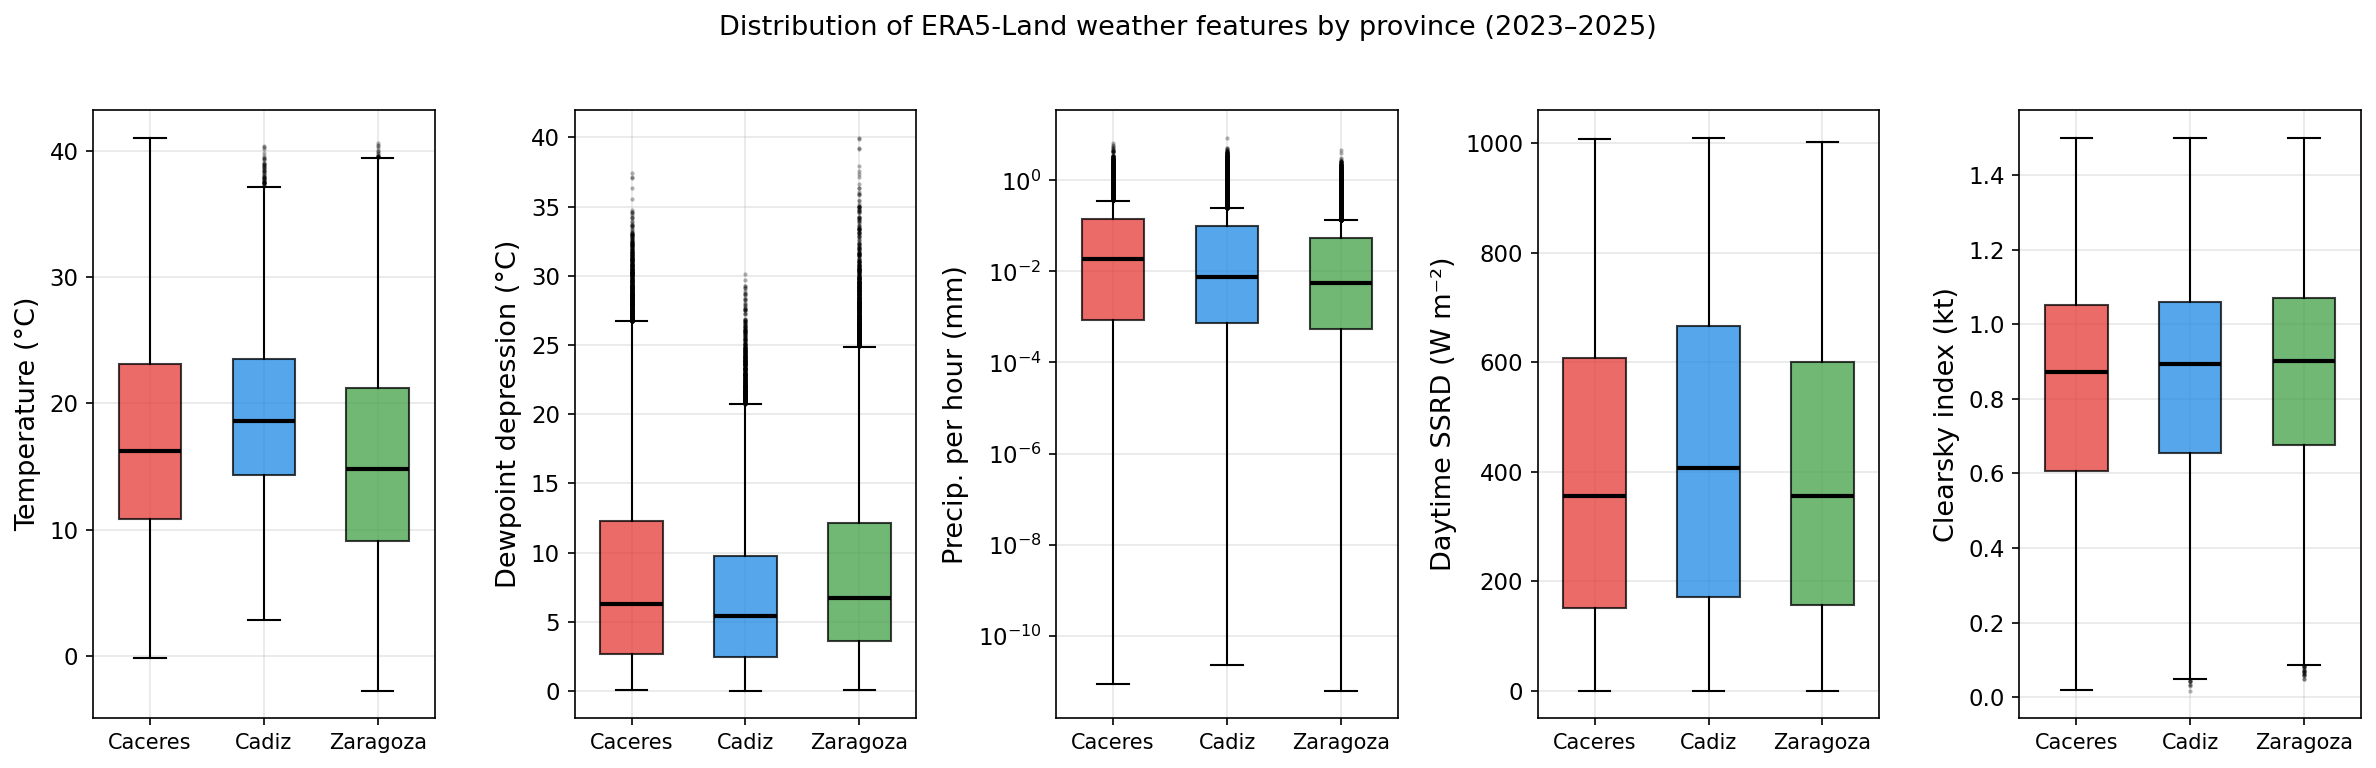

Saved: province_weather_distributions.png


In [ ]:
FEATURES = [
    ('temperature_2m_C',       'Temperature (°C)',        False),
    ('dewpoint_depression_C',  'Dewpoint depression (°C)', False),
    ('total_precip_mm',        'Precip. per hour (mm)',    True),   # log-scale
    ('ssrd_wm2',               'Daytime SSRD (W m⁻²)',    False),
    ('kt',                     'Clearsky index (kt)',      False),
]

prov_labels = list(PROVINCES.keys())
colors      = [PROVINCES[p]['color'] for p in prov_labels]

fig, axes = plt.subplots(1, len(FEATURES), figsize=(16, 5))

for ax, (feat, ylabel, logscale) in zip(axes, FEATURES):
    data = []
    for prov in prov_labels:
        df = dfs[prov]
        if feat == 'ssrd_wm2' or feat == 'kt':
            col = df[df['is_daytime']][feat].dropna()
        elif feat == 'total_precip_mm':
            col = df[feat]
            col = col[col > 0]  # non-zero only so log makes sense
        else:
            col = df[feat].dropna()
        data.append(col.values)

    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='.', ms=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticklabels([p.replace('á','a').replace('á','a') for p in prov_labels],
                        fontsize=10)
    ax.set_ylabel(ylabel)
    if logscale:
        ax.set_yscale('log')

plt.suptitle('Distribution of ERA5-Land weather features by province (2023–2025)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'province_weather_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/province_weather_distributions.png')

## 7. Correlation Heatmaps — Features vs. PV Generation

Pearson correlation of each daytime feature with PV generation, per province.
Shows which predictors are most important in each climate — useful for the Methods section.

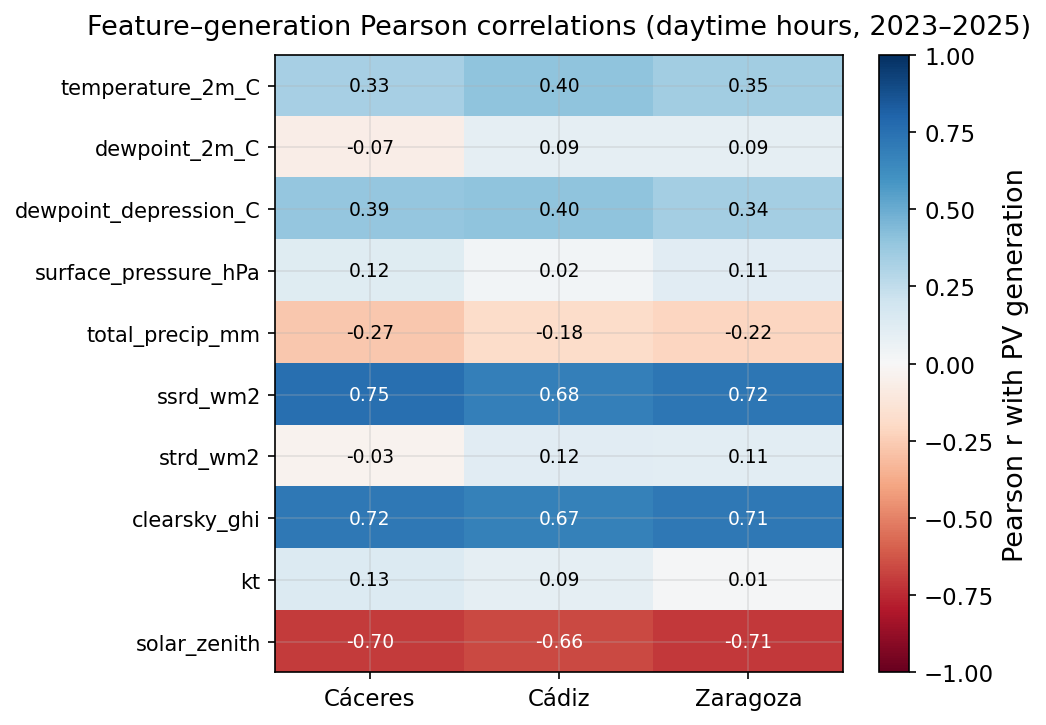

Saved: province_feature_correlations.png

                       Cáceres  Cádiz  Zaragoza
temperature_2m_C         0.335  0.401     0.346
dewpoint_2m_C           -0.065  0.090     0.091
dewpoint_depression_C    0.388  0.401     0.339
surface_pressure_hPa     0.120  0.024     0.110
total_precip_mm         -0.267 -0.182    -0.216
ssrd_wm2                 0.750  0.683     0.722
strd_wm2                -0.033  0.117     0.109
clearsky_ghi             0.715  0.672     0.715
kt                       0.134  0.086     0.010
solar_zenith            -0.703 -0.662    -0.709


In [ ]:
import matplotlib.colors as mcolors

CORR_FEATURES = [
    'temperature_2m_C', 'dewpoint_2m_C', 'dewpoint_depression_C',
    'surface_pressure_hPa', 'total_precip_mm',
    'ssrd_wm2', 'strd_wm2', 'clearsky_ghi', 'kt',
    'solar_zenith',
]

corr_data = {}
for prov, df in dfs.items():
    day = df[df['is_daytime']].copy()
    corrs = {}
    for feat in CORR_FEATURES:
        if feat in day.columns:
            corrs[feat] = day[feat].corr(day['pv_generation_mwh'])
    corr_data[prov] = corrs

corr_df = pd.DataFrame(corr_data)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_df.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, fontsize=11)
ax.set_yticks(range(len(corr_df.index)))
ax.set_yticklabels(corr_df.index, fontsize=10)

# Annotate with correlation values
for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        val = corr_df.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color='black' if abs(val) < 0.6 else 'white')

plt.colorbar(im, ax=ax, label='Pearson r with PV generation')
ax.set_title('Feature–generation Pearson correlations (daytime hours, 2023–2025)', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'province_feature_correlations.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/province_feature_correlations.png')
print()
print(corr_df.round(3).to_string())

## 8. Summary: Key Differences at a Glance

In [20]:
print('=' * 68)
print('PROVINCE CLIMATE SUMMARY — KEY DIFFERENCES')
print('=' * 68)
print(f'{"Statistic":<35s} {"Cáceres":>10s} {"Cádiz":>10s} {"Zaragoza":>10s}')
print('-' * 68)

lines = [
    ('Region',               'Extremadura',  'Andalucía',    'Aragón'),
    ('Climate type',         'Inland arid',  'Atl. coastal', 'Ebro valley'),
    ('Installed capacity',   '2,463 MWp',    '715 MWp',      '462 MWp'),
    ('---', '', '', ''),
    ('Mean temperature (°C)',    '17.3',  '19.2',  '15.5'),
    ('Temp. range (°C)',         '–0.2–41.1', '2.8–40.4', '–2.8–40.6'),
    ('Mean dewpoint (°C)',       '8.8',   '12.4',  '6.8'),
    ('Dewpoint depression (°C)', '8.5',   '6.8',   '8.7'),
    ('Annual precip. (mm/yr)',   '716',   '562',   '397'),
    ('Mean pressure (hPa)',      '973',   '1,009', '954'),
    ('---', '', '', ''),
    ('Daytime SSRD (W/m²)',      '395',   '431',   '389'),
    ('Clearsky index kt',        '0.946', '0.972', '1.028'),
    ('Cloudy fraction (kt<0.5)', '~see table', '~see table', '~see table'),
]

for label, c, ca, z in lines:
    if label == '---':
        print('-' * 68)
    else:
        print(f'{label:<35s} {c:>10s} {ca:>10s} {z:>10s}')

print('=' * 68)
print()
print('Notable differences:')
print('  • Temperature:   Cádiz warmest (+3.7°C vs Zaragoza), mildest winters (min 2.8°C)')
print('  • Humidity:      Cádiz most humid (dewpt 12.4°C, depression only 6.8°C)')
print('  • Precipitation: Cáceres wettest (716 mm/yr), Zaragoza driest (397 mm/yr)')
print('  • Pressure:      Cádiz near sea level (1009 hPa) vs Zaragoza elevated (954 hPa)')
print('  • Solar:         Cádiz has highest daytime SSRD; Zaragoza kt>1 (extremely clear sky)')
print('  • Variability:   Cádiz coastal weather = higher cloud cover variability (lower kt std)')

PROVINCE CLIMATE SUMMARY — KEY DIFFERENCES
Statistic                              Cáceres      Cádiz   Zaragoza
--------------------------------------------------------------------
Region                              Extremadura  Andalucía     Aragón
Climate type                        Inland arid Atl. coastal Ebro valley
Installed capacity                   2,463 MWp    715 MWp    462 MWp
--------------------------------------------------------------------
Mean temperature (°C)                     17.3       19.2       15.5
Temp. range (°C)                     –0.2–41.1   2.8–40.4  –2.8–40.6
Mean dewpoint (°C)                         8.8       12.4        6.8
Dewpoint depression (°C)                   8.5        6.8        8.7
Annual precip. (mm/yr)                     716        562        397
Mean pressure (hPa)                        973      1,009        954
--------------------------------------------------------------------
Daytime SSRD (W/m²)                        395        4